In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("train.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
# We want to predict if a person will survive or not

# Missing value Treatment

In [3]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [4]:
df.shape

(891, 12)

In [ ]:
#Information about 891 passen

In [6]:
df.dropna().shape

(183, 12)

# Check the %

In [7]:
(df.isnull().sum()/891)*100 #column wise missing vlaue

PassengerId     0.000000
Survived        0.000000
Pclass          0.000000
Name            0.000000
Sex             0.000000
Age            19.865320
SibSp           0.000000
Parch           0.000000
Ticket          0.000000
Fare            0.000000
Cabin          77.104377
Embarked        0.224467
dtype: float64

In [8]:
round((df.isnull().sum()/891)*100,2) #column wise missing vlaue

PassengerId     0.00
Survived        0.00
Pclass          0.00
Name            0.00
Sex             0.00
Age            19.87
SibSp           0.00
Parch           0.00
Ticket          0.00
Fare            0.00
Cabin          77.10
Embarked        0.22
dtype: float64

In [9]:
df.drop("Cabin",inplace=True,axis=1)# axis=1 columns #inplace = Permant

In [10]:
round((df.isnull().sum()/891)*100,2) #column wise missing vlaue

PassengerId     0.00
Survived        0.00
Pclass          0.00
Name            0.00
Sex             0.00
Age            19.87
SibSp           0.00
Parch           0.00
Ticket          0.00
Fare            0.00
Embarked        0.22
dtype: float64

# Outlier

In [15]:
import seaborn as sns

<Axes: xlabel='Age'>

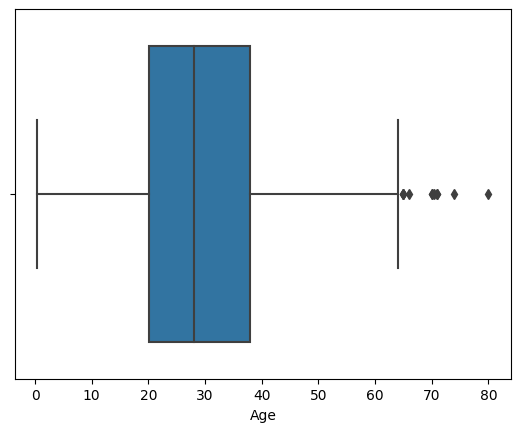

In [19]:
sns.boxplot(x = df.Age)

In [21]:
df.Age.median()

28.0

In [22]:
df.Age.mean()

29.69911764705882

In [24]:
df.Age.fillna(df.Age.median(),inplace=True)

In [25]:
round((df.isnull().sum()/891)*100,2) #column wise missing vlaue

Survived    0.00
Pclass      0.00
Name        0.00
Sex         0.00
Age         0.00
SibSp       0.00
Parch       0.00
Ticket      0.00
Fare        0.00
Embarked    0.22
dtype: float64

In [26]:
df

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S
...,...,...,...,...,...,...,...,...,...,...
886,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,S
887,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,S
888,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,28.0,1,2,W./C. 6607,23.4500,S
889,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C


In [32]:
def title(x):
    if 'Mr.' in x:
        return "Mr"
    elif 'Miss.' in x:
        return "Miss"
    elif 'Mrs.' in x:
        return "Mrs"
    else:
        return "Normal"
    

In [33]:
df['title'] =  df['Name'].apply(title)

In [34]:
df

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,title
0,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,Mr
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,Mrs
2,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,Miss
3,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,Mrs
4,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,Mr
...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,S,Normal
887,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,S,Miss
888,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,28.0,1,2,W./C. 6607,23.4500,S,Miss
889,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C,Mr


In [35]:
round((df.isnull().sum()/891)*100,2) #column wise missing vlaue

Survived    0.00
Pclass      0.00
Name        0.00
Sex         0.00
Age         0.00
SibSp       0.00
Parch       0.00
Ticket      0.00
Fare        0.00
Embarked    0.22
title       0.00
dtype: float64

In [37]:
df.Embarked.mode()[0]

'S'

In [38]:
df.Embarked.fillna(df.Embarked.mode()[0],inplace=True)

In [39]:
round((df.isnull().sum()/891)*100,2) #column wise missing vlaue

Survived    0.0
Pclass      0.0
Name        0.0
Sex         0.0
Age         0.0
SibSp       0.0
Parch       0.0
Ticket      0.0
Fare        0.0
Embarked    0.0
title       0.0
dtype: float64

In [40]:
df

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,title
0,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,Mr
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,Mrs
2,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,Miss
3,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,Mrs
4,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,Mr
...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,S,Normal
887,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,S,Miss
888,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,28.0,1,2,W./C. 6607,23.4500,S,Miss
889,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C,Mr


In [41]:
df.drop(['Ticket','Name'],axis=1,inplace=True)

In [42]:
df

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,title
0,0,3,male,22.0,1,0,7.2500,S,Mr
1,1,1,female,38.0,1,0,71.2833,C,Mrs
2,1,3,female,26.0,0,0,7.9250,S,Miss
3,1,1,female,35.0,1,0,53.1000,S,Mrs
4,0,3,male,35.0,0,0,8.0500,S,Mr
...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Normal
887,1,1,female,19.0,0,0,30.0000,S,Miss
888,0,3,female,28.0,1,2,23.4500,S,Miss
889,1,1,male,26.0,0,0,30.0000,C,Mr


# Encoding

In [54]:
df = pd.get_dummies(df,drop_first=True)

In [55]:
df

,Survived,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S,title_Mr,title_Mrs,title_Normal
0,0,3,22.0,1,0,7.2500,1,0,1,1,0,0
1,1,1,38.0,1,0,71.2833,0,0,0,0,1,0
2,1,3,26.0,0,0,7.9250,0,0,1,0,0,0
3,1,1,35.0,1,0,53.1000,0,0,1,0,1,0
4,0,3,35.0,0,0,8.0500,1,0,1,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,27.0,0,0,13.0000,1,0,1,0,0,1
887,1,1,19.0,0,0,30.0000,0,0,1,0,0,0
888,0,3,28.0,1,2,23.4500,0,0,1,0,0,0
889,1,1,26.0,0,0,30.0000,1,0,0,1,0,0


In [56]:
X = df.iloc[:,1:]
y = df.iloc[:,0]

In [57]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [58]:
from sklearn import tree
dt = tree.DecisionTreeClassifier()

In [59]:
dt.fit(X_train,y_train)

DecisionTreeClassifier()

In [61]:
#ypred = dt.predict(X_test)

In [62]:
dt.score(X_test,y_test)

0.8100558659217877

In [63]:
 from sklearn.linear_model import LogisticRegression

In [64]:
log = LogisticRegression()

In [65]:
log.fit(X_train,y_train) #Fit only works on your training data

C:\Users\AKASH\miniconda3\lib\site-packages\sklearn\linear_model\_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [66]:
X

,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S,title_Mr,title_Mrs,title_Normal
0,3,22.0,1,0,7.2500,1,0,1,1,0,0
1,1,38.0,1,0,71.2833,0,0,0,0,1,0
2,3,26.0,0,0,7.9250,0,0,1,0,0,0
3,1,35.0,1,0,53.1000,0,0,1,0,1,0
4,3,35.0,0,0,8.0500,1,0,1,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...
886,2,27.0,0,0,13.0000,1,0,1,0,0,1
887,1,19.0,0,0,30.0000,0,0,1,0,0,0
888,3,28.0,1,2,23.4500,0,0,1,0,0,0
889,1,26.0,0,0,30.0000,1,0,0,1,0,0


In [67]:
from sklearn.preprocessing import MinMaxScaler
minmax = MinMaxScaler()
minmax.fit_transform(df)

array([[0.        , 1.        , 0.27117366, ..., 1.        , 0.        ,
        0.        ],
       [1.        , 0.        , 0.4722292 , ..., 0.        , 1.        ,
        0.        ],
       [1.        , 1.        , 0.32143755, ..., 0.        , 0.        ,
        0.        ],
       ...,
       [0.        , 1.        , 0.34656949, ..., 0.        , 0.        ,
        0.        ],
       [1.        , 0.        , 0.32143755, ..., 1.        , 0.        ,
        0.        ],
       [0.        , 1.        , 0.39683338, ..., 1.        , 0.        ,
        0.        ]])

In [73]:
df = pd.DataFrame(minmax.fit_transform(df),columns=df.columns)

In [74]:
X = df.iloc[:,1:]
y = df.iloc[:,0]

In [75]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [76]:
log.fit(X_train,y_train)

LogisticRegression()

In [77]:
ypred = log.predict(X_test)

In [78]:
from sklearn.metrics import accuracy_score

In [79]:
accuracy_score(y_test,ypred)

0.776536312849162

In [80]:
from sklearn.ensemble import RandomForestClassifier

In [81]:
rc = RandomForestClassifier()

In [82]:
rc.fit(X_train,y_train) #learns the value of m and c

RandomForestClassifier()

In [83]:
y_pred = rc.predict(X_test)

In [84]:
accuracy_score(y_test,y_pred)

0.8324022346368715

In [87]:
y_pred

array([1., 0., 0., 1., 0., 1., 1., 0., 1., 1., 0., 0., 0., 0., 0., 1., 0.,
       1., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 1.,
       0., 0., 1., 1., 1., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 1.,
       1., 0., 1., 0., 1., 0., 1., 1., 0., 0., 1., 1., 0., 0., 1., 0., 0.,
       0., 1., 1., 1., 1., 1., 0., 0., 1., 1., 1., 1., 0., 1., 1., 0., 0.,
       0., 1., 1., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0.,
       1., 0., 0., 1., 1., 0., 0., 0., 1., 0., 1., 1., 0., 0., 0., 0., 1.,
       0., 0., 1., 1., 1., 0., 0., 1., 0., 1., 0., 1., 1., 0., 1., 1., 0.,
       1., 0., 0., 0., 0., 1., 1., 0., 0., 1., 0., 1., 1., 0., 0., 0., 0.,
       1., 0., 0., 0., 1., 1., 1., 0., 1., 0., 1., 0., 0., 0., 1., 0., 0.,
       0., 1., 1., 1., 0., 0., 0., 1., 1.])

In [89]:
X_test

,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S,title_Mr,title_Mrs,title_Normal
709,1.0,0.346569,0.125,0.166667,0.029758,1.0,0.0,0.0,0.0,0.0,1.0
439,0.5,0.384267,0.000,0.000000,0.020495,1.0,0.0,1.0,1.0,0.0,0.0
840,1.0,0.246042,0.000,0.000000,0.015469,1.0,0.0,1.0,1.0,0.0,0.0
720,0.5,0.070118,0.000,0.166667,0.064412,0.0,0.0,1.0,0.0,0.0,0.0
39,1.0,0.170646,0.125,0.000000,0.021942,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...
433,1.0,0.208344,0.000,0.000000,0.013907,1.0,0.0,1.0,1.0,0.0,0.0
773,1.0,0.346569,0.000,0.000000,0.014102,1.0,0.0,0.0,1.0,0.0,0.0
25,1.0,0.472229,0.125,0.833333,0.061264,0.0,0.0,1.0,0.0,1.0,0.0
84,0.5,0.208344,0.000,0.000000,0.020495,0.0,0.0,1.0,0.0,0.0,0.0


In [90]:
X_test['pred'] = y_pred

In [91]:
X_test

,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S,title_Mr,title_Mrs,title_Normal,pred
709,1.0,0.346569,0.125,0.166667,0.029758,1.0,0.0,0.0,0.0,0.0,1.0,1.0
439,0.5,0.384267,0.000,0.000000,0.020495,1.0,0.0,1.0,1.0,0.0,0.0,0.0
840,1.0,0.246042,0.000,0.000000,0.015469,1.0,0.0,1.0,1.0,0.0,0.0,0.0
720,0.5,0.070118,0.000,0.166667,0.064412,0.0,0.0,1.0,0.0,0.0,0.0,1.0
39,1.0,0.170646,0.125,0.000000,0.021942,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
433,1.0,0.208344,0.000,0.000000,0.013907,1.0,0.0,1.0,1.0,0.0,0.0,0.0
773,1.0,0.346569,0.000,0.000000,0.014102,1.0,0.0,0.0,1.0,0.0,0.0,0.0
25,1.0,0.472229,0.125,0.833333,0.061264,0.0,0.0,1.0,0.0,1.0,0.0,0.0
84,0.5,0.208344,0.000,0.000000,0.020495,0.0,0.0,1.0,0.0,0.0,0.0,1.0
